<h1 style = "color: purple; text-align: center;font-family: Poppins; font-weight: 800;">Purchase Power Prediction (PPP)</h1>

In [25]:
import mlflow
import mlflow.sklearn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.model_selection import train_test_split
from mlflow.models.signature import infer_signature

In [6]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Purchase Power Experiment")

<Experiment: artifact_location=('file:C:/Users/nithis '
 'kumar/OneDrive/Desktop/DATASCIENCE/Projects/Purchase-Power-Prediction-PPP-/notebook/mlruns/1'), creation_time=1782487691583, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782487691583, lifecycle_stage='active', name='Purchase Power Experiment', tags={}, trace_location=None, workspace='default'>

In [7]:
mlflow.sklearn.autolog(log_input_examples=True)

### **LOAD DATASET**

In [15]:
df = pd.read_csv(r"../data/purchase_power.csv", index_col=0)

In [16]:
df.head()

,age,income,savings_rate,debt_ratio,purchase_power,purchasing_power
0,57,52651.67,0.07,0.42,21029.01,22.28
1,47,57833.38,0.22,0.43,23525.62,24.03
2,33,91580.17,0.22,0.52,27732.16,26.97
3,26,42537.86,0.22,0.39,14752.88,17.89
4,39,50845.70,0.29,0.33,24869.56,24.96


### **EDA & Visualization**

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               5000 non-null   int64  
 1   income            5000 non-null   float64
 2   savings_rate      5000 non-null   float64
 3   debt_ratio        5000 non-null   float64
 4   purchase_power    5000 non-null   float64
 5   purchasing_power  5000 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 273.4 KB


In [18]:
df.dtypes

age                   int64
income              float64
savings_rate        float64
debt_ratio          float64
purchase_power      float64
purchasing_power    float64
dtype: object

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,39.201400,11.788818,19.00,29.0000,39.000,50.0000,59.00
income,5000.0,60000.000042,20002.000260,12460.09,46807.8975,56696.150,69314.6275,189508.83
savings_rate,5000.0,0.175134,0.072856,0.05,0.1100,0.170,0.2400,0.30
debt_ratio,5000.0,0.354324,0.143712,0.10,0.2300,0.360,0.4800,0.60
purchase_power,5000.0,28166.238322,15483.454541,-9409.05,17527.1725,26507.795,37061.5000,132198.03
purchasing_power,5000.0,27.269608,10.824723,1.00,19.8300,26.110,33.4900,100.00


In [22]:
df.duplicated().sum()

np.int64(0)

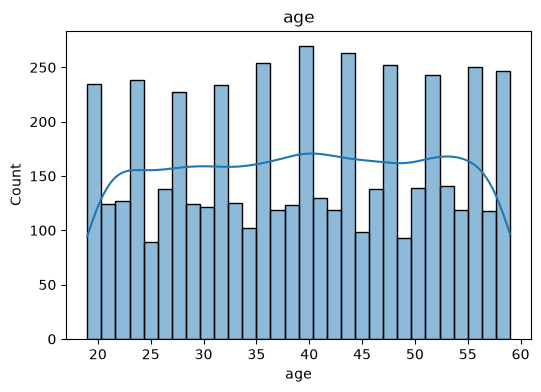

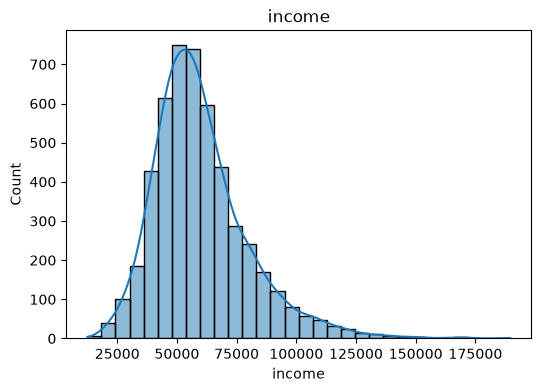

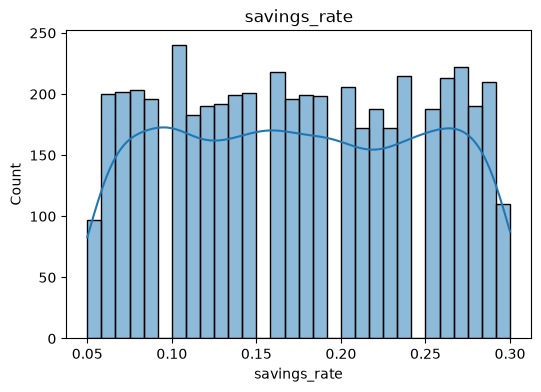

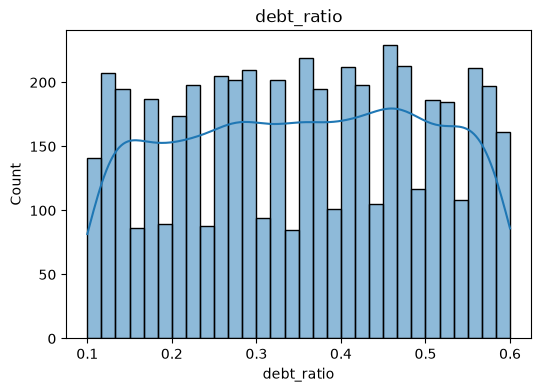

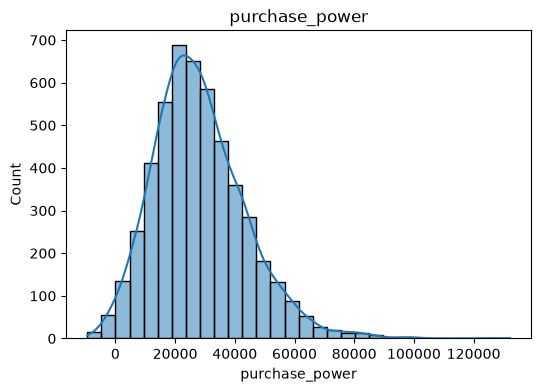

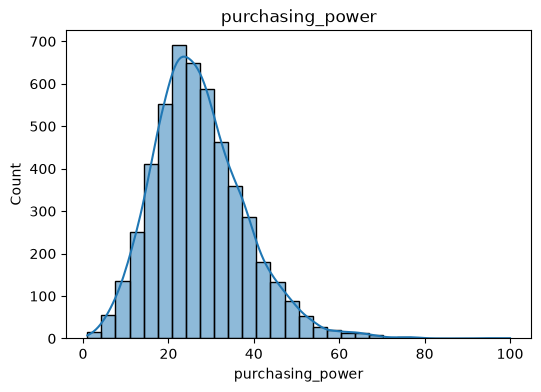

In [26]:
for col in df.columns:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col],
                 kde=True,
                 bins=30)

    plt.title(col)

    plt.show()

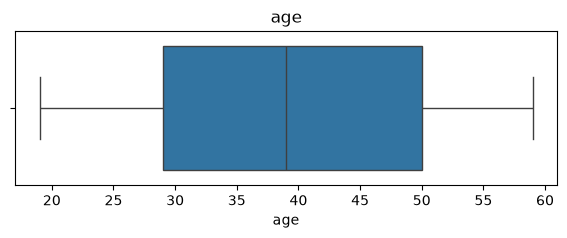

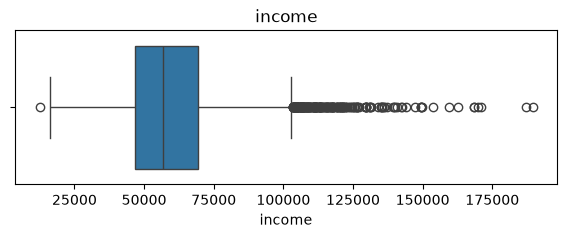

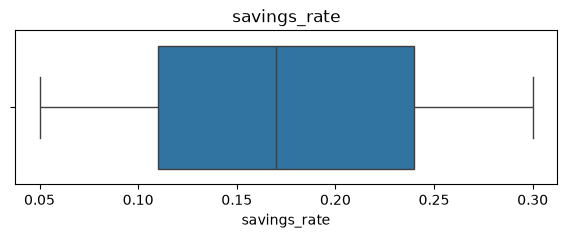

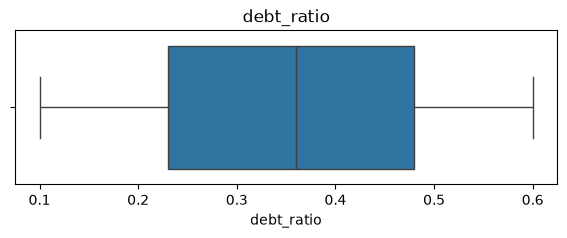

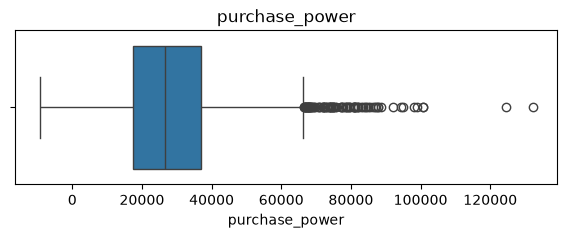

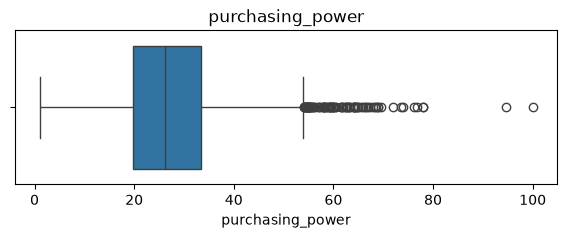

In [28]:
for col in df.columns:

    plt.figure(figsize=(7,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

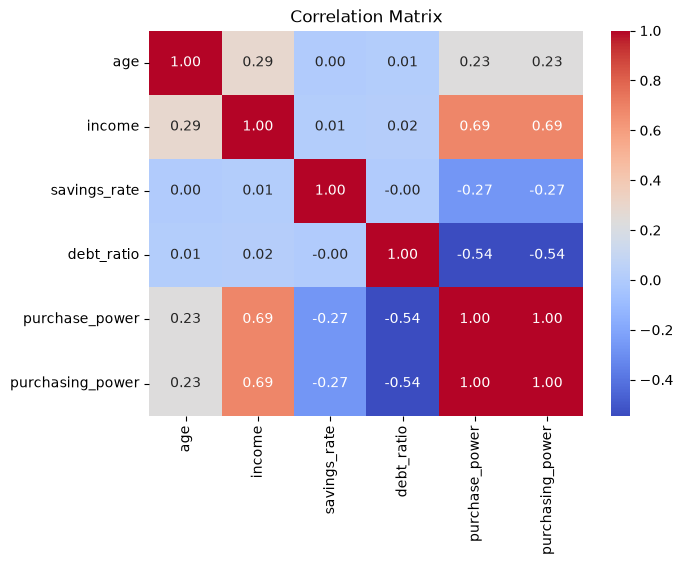

In [33]:
corr = df.corr()

plt.figure(figsize=(7,5))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

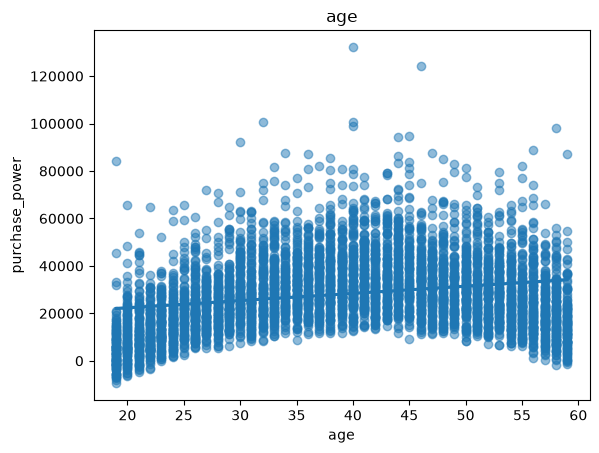

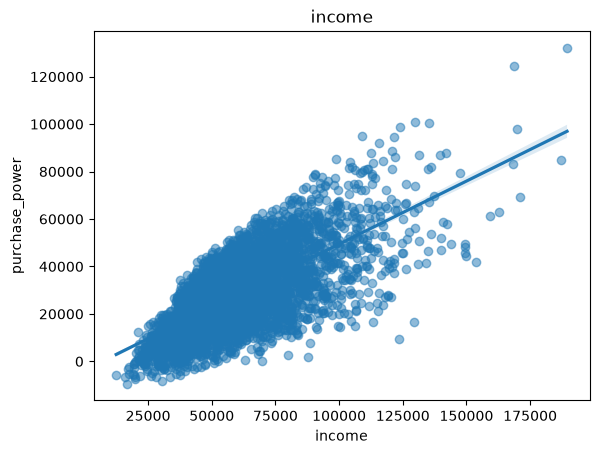

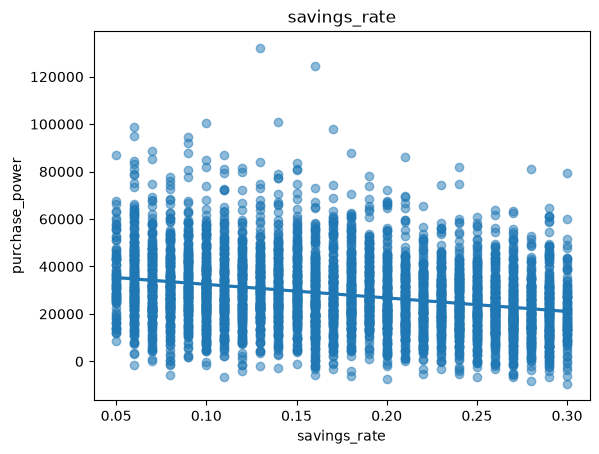

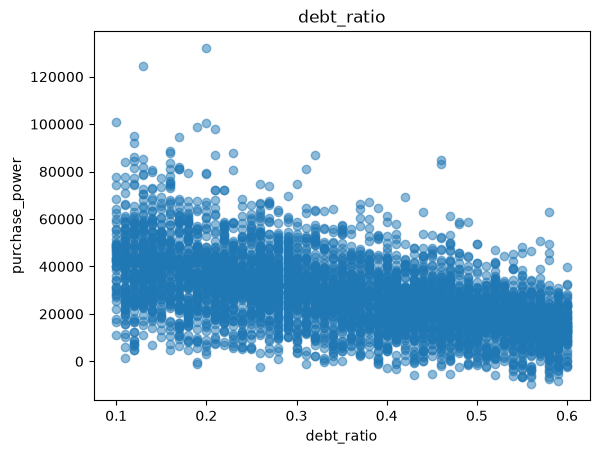

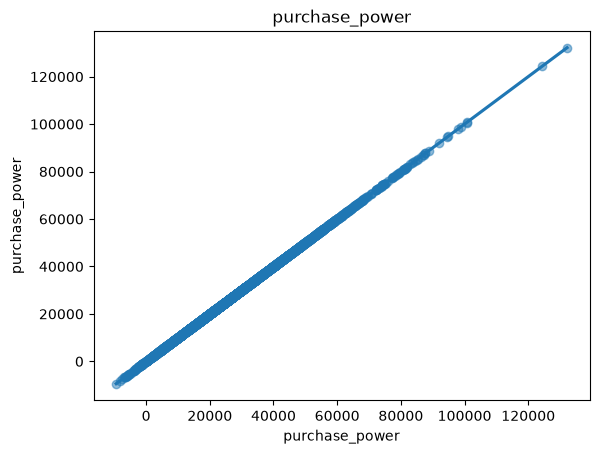

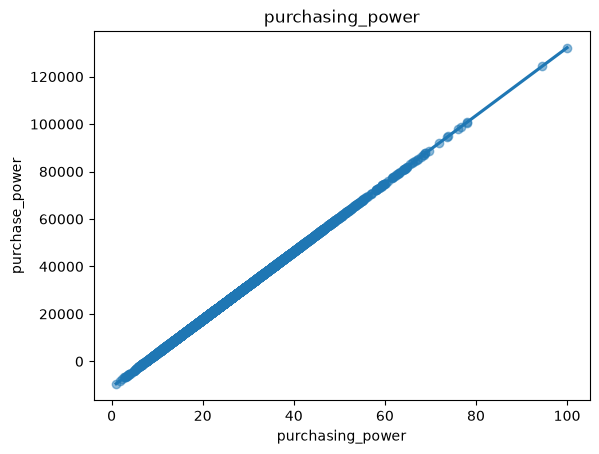

In [36]:
target="purchase_power"

for col in df.columns:

    sns.regplot(
        data=df,
        x=col,
        y=target,
        scatter_kws={"alpha":0.5}
    )

    plt.title(col)

    plt.show()

### **Feature Engineering**

Create a feature to classify the potential purchasing capacity customers

In [50]:
df["purchase_class"] = (df["purchasing_power"] > 27).astype(int)

In [65]:
df["purchase_class"].value_counts()

purchase_class
0    2694
1    2306
Name: count, dtype: int64

### **Model Training**

In [52]:
X = df.drop(["purchase_power", "purchasing_power", "purchase_class"], axis=1)
y = df.purchase_class

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

In [60]:
#Hyperparameters

params = {
    "C": 1.0,
    "solver": "liblinear",
    "max_iter": 200,
    "random_state": 42,
}

In [63]:
with mlflow.start_run(run_name="LogisticRegression"):

    # Model
    model = LogisticRegression(**params)

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Manual Parameter Logging
    mlflow.log_params(params)

    
    # Manual Metric Logging
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Confusion Matrix

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot()

    plt.savefig("confusion_matrix.png")
    plt.close()

    mlflow.log_artifact("confusion_matrix.png")
    
    signature = infer_signature(
        X_train,
        model.predict(X_train)
    )

    mlflow.sklearn.log_model(
    sk_model=model,
    artifact_path="model",
    signature=signature,
    input_example=X_train[:5],
    )

    print("\nTraining Completed")
    print(f"Accuracy : {accuracy:.4f}")

2026/06/26 21:37:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\nithis kumar\OneDrive\Desktop\Conda-Envs\py314\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/26 21:37:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\nithis kumar\On

C:\Users\nithis kumar\OneDrive\Desktop\Conda-Envs\py314\Lib\site-packages\sklearn\metrics\_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(
2026/06/26 21:37:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\nithis kumar\OneDrive\Desktop\Conda-Envs\py314\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Mi

2026/06/26 21:38:23 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\nithis kumar\OneDrive\Desktop\Conda-Envs\py314\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."



Training Completed
Accuracy : 0.5973
